# GEV responses

Fit a generalized extreme value (GEV) regression with separate predictors for
location, scale, and shape. The distinctive difficulty is **parameter-dependent
support**: finite parameter values do not guarantee that the observations have
positive density. We check a feasible initial state before sampling and compare
the fitted curves with known simulation functions.

This self-contained example assumes {doc}`01c-transform` and uses
[Liesel-GAM](https://liesel-gam.readthedocs.io/latest/) 0.2.4 for additive terms.
For the general distributional regression workflow, see
{doc}`../notebooks/12-model-predictions`; for sampler checks, see
{doc}`../../goose-diagnostics`.

## Simulate three predictors

The GEV distribution describes a limit for suitably normalized block maxima.
Here the responses are simulated directly to isolate the modeling workflow;
real block-maxima analyses also need to justify block construction and the
extreme-value approximation.

We use independent covariates on $[0,1]$:

$$
\mu_i=\sin(2\pi x_{0i}),\qquad
\log\sigma_i=-0.5+0.4x_{1i},\qquad
\xi_i=0.15+0.1x_{2i}.
$$

`concentration` is TensorFlow Probability's name for $\xi$. The GEV location
$\mu$ is not generally its expected value, and its positive scale $\sigma$ is
not its standard deviation.

In [1]:
import jax
import jax.numpy as jnp
import liesel_gam as gam
import numpy as np
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

key_x, key_y = jax.random.split(jax.random.key(13))
x = jax.random.uniform(key_x, (500, 3))
true_loc = jnp.sin(2.0 * jnp.pi * x[:, 0])
true_scale = jnp.exp(-0.5 + 0.4 * x[:, 1])
true_concentration = 0.15 + 0.1 * x[:, 2]

response = tfd.GeneralizedExtremeValue(
    loc=true_loc,
    scale=true_scale,
    concentration=true_concentration,
).sample(seed=key_y)

data = pd.DataFrame(
    {
        "x0": np.asarray(x[:, 0]),
        "x1": np.asarray(x[:, 1]),
        "x2": np.asarray(x[:, 2]),
        "y": np.asarray(response),
    },
)

(plot-data)=

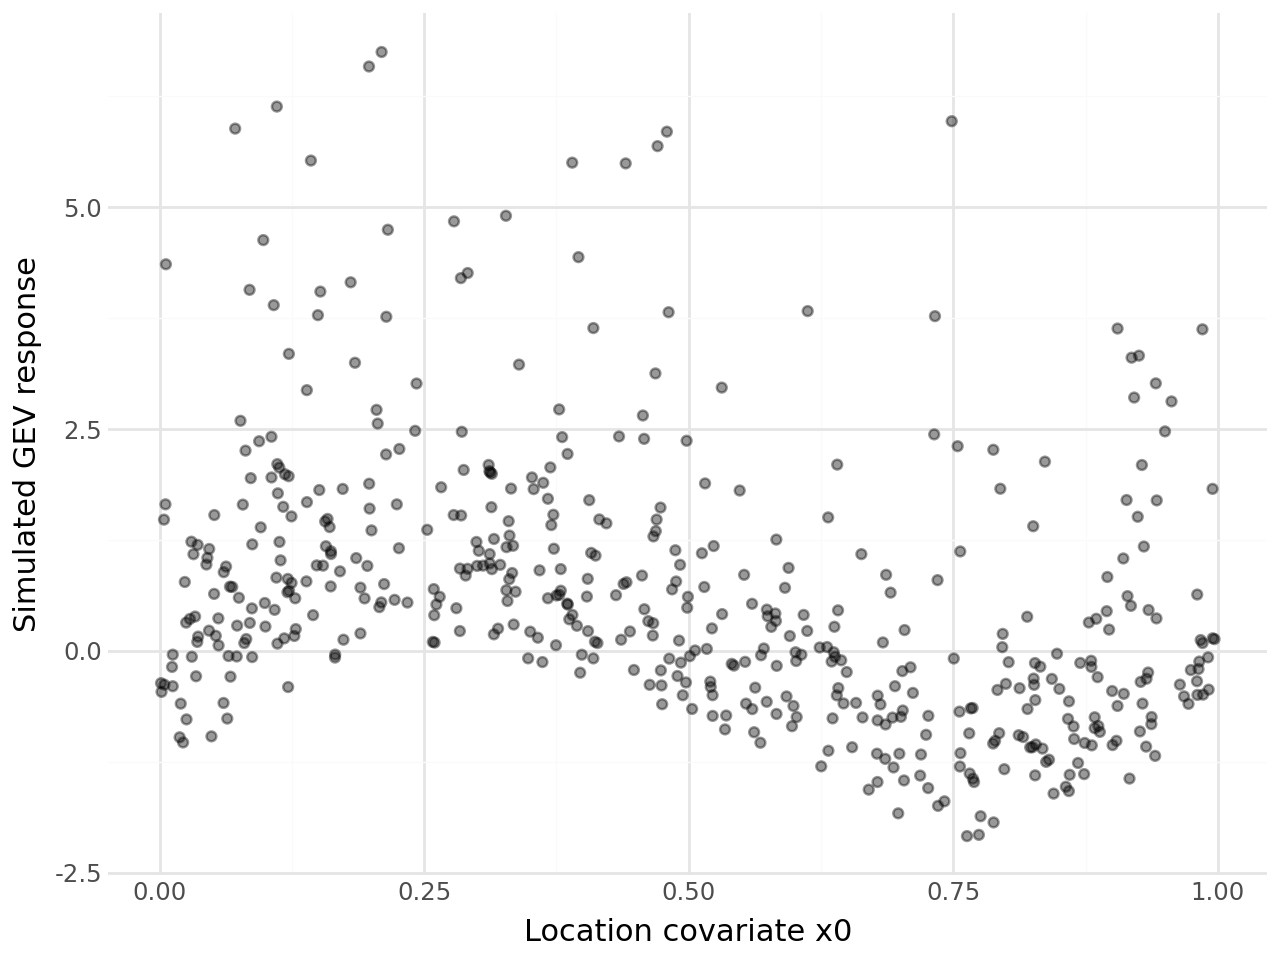

In [2]:
(
    p9.ggplot(data, p9.aes("x0", "y"))
    + p9.geom_point(alpha=0.4)
    + p9.labs(x="Location covariate x0", y="Simulated GEV response")
    + p9.theme_minimal()
)

## Define the model

The location uses a centered P-spline and an intercept with a
$\operatorname{Normal}(0,2)$ prior. Its smoothing variance has the default
$\operatorname{InverseGamma}(1,0.005)$ prior. The scale and shape use linear
predictors with intercepts: coefficients have independent normal priors with
standard deviations 1 and 0.3, respectively. The shape intercept prior is
centered at 0.1; all other linear coefficients are centered at zero.

The exponential link ensures a positive scale. The identity link for shape
allows both positive and negative shapes. Restricting shape to be positive
would be a substantive tail assumption, not just a numerical convenience.

In [3]:
registry = gam.PandasRegistry(data)
tb = gam.TermBuilder(registry)

location_intercept = lsl.Var.new_param(
    float(data["y"].median()),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.0),
    name="location_intercept",
)

loc = gam.AdditivePredictor("loc", intercept=location_intercept)
scale = gam.AdditivePredictor("scale", inv_link=jnp.exp, intercept=False)
concentration = gam.AdditivePredictor("concentration", intercept=False)

loc_smooth = tb.ps("x0", k=10)
scale_linear = tb.lin(
    "x1",
    name="log_scale",
    include_intercept=True,
    prior=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
)

shape_linear = tb.lin(
    "x2",
    name="shape",
    include_intercept=True,
    prior=lsl.Dist(
        tfd.Normal,
        loc=jnp.array([0.1, 0.0]),
        scale=0.3,
    ),
)

loc += loc_smooth
scale += scale_linear
concentration += shape_linear

# Start with constant predictors, away from the xi = 0 limiting case.
scale_linear.coef.value = jnp.array([np.log(data["y"].std()), 0.0])
shape_linear.coef.value = jnp.array([0.1, 0.0])
scale.update()
concentration.update()

y = lsl.Var.new_obs(
    data["y"].to_numpy(),
    dist=lsl.Dist(
        tfd.GeneralizedExtremeValue,
        loc=loc,
        scale=scale,
        concentration=concentration,
    ),
    name="y",
)
model = lsl.Model(y)

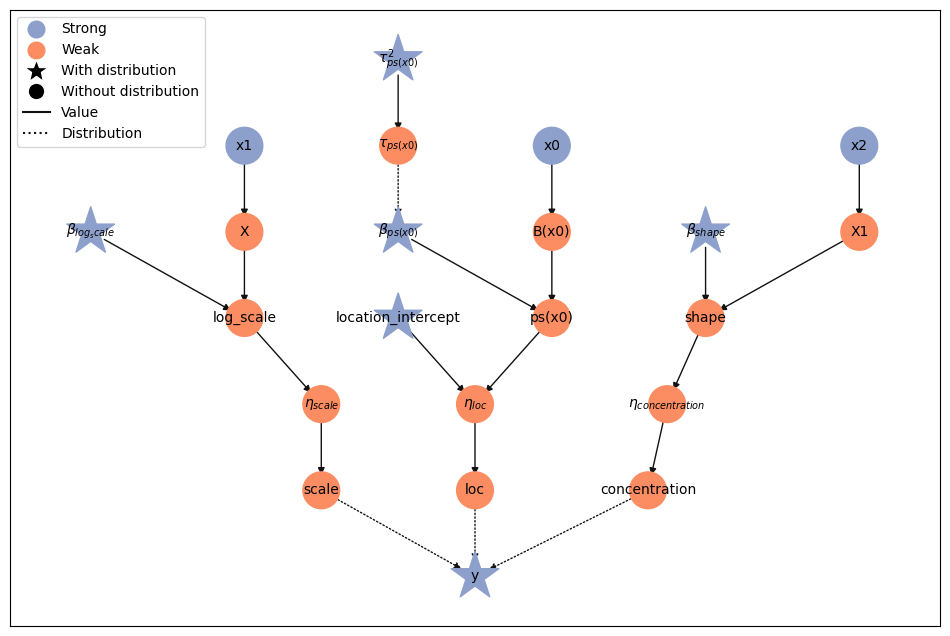

In [4]:
model.plot(width=12, height=8)

## Check support and starts

For $\xi_i\ne0$, the interior support requires

$$
1+\xi_i\frac{y_i-\mu_i}{\sigma_i}>0.
$$

Positive shape gives a lower endpoint; negative shape gives an upper endpoint.
At $\xi=0$ the distribution has its Gumbel limit with support on the real line.
The [TensorFlow Probability GEV documentation](https://www.tensorflow.org/probability/api_docs/python/tfp/distributions/GeneralizedExtremeValue)
describes this parameterization. Values near the endpoint or the limiting case
can make gradients and curvature numerically difficult.

The constant initial predictors below put all these observations inside the
support. A positive minimum margin checks support at this state; finite log
density alone does not establish usable gradients or good sampling. With other
data, revise the starting location, scale, or shape if this check fails. Do not
clip observations or silently alter the likelihood to force a valid start.

In [5]:
support_margin = 1.0 + concentration.value * (y.value - loc.value) / scale.value
initial_checks = pd.Series(
    {
        "minimum support margin": float(jnp.min(support_margin)),
        "initial log density": float(model.log_prob),
        "initial shape": float(concentration.value[0]),
    },
)

In [6]:
initial_checks.round(3)

minimum support margin      0.838
initial log density      -907.250
initial shape               0.100
dtype: float64

We use one NUTS block for all regression coefficients, leaving the smoothing
variance's automatic Gibbs update intact. Small, bounded uniform perturbations
give different coefficient starts; a positive multiplicative perturbation also
disperses the smoothing variance. The coefficient perturbations are suitable
for the generous support margin of this example; changing data or jitter requires rechecking starts.
For explicit per-chain states and mode-based initialization, see
{doc}`../../goose-initialization`.

In [7]:
joint_coefficients = gs.MCMCSpec(
    gs.NUTSKernel,
    kernel_group="regression",
    jitter_dist=tfd.Uniform(-0.01, 0.01),
)

for parameter in [
    location_intercept,
    loc_smooth.coef,
    scale_linear.coef,
    shape_linear.coef,
]:
    parameter.inference = joint_coefficients

smoothing_variance = loc_smooth.scale.value_node[0]
smoothing_variance.inference.jitter_dist = tfd.LogNormal(0.0, 0.1)
smoothing_variance.inference.jitter_method = "multiplicative"

## Sample and inspect

Adapt NUTS before retaining draws. Gibbs samples the smoothing **variance**
$\tau^2$; the spline's `scale` variable is its square root $\tau$.

In [8]:
results = gs.LieselMCMC(model).run_for_epochs(
    seed=2026,
    num_chains=4,
    adaptation=1000,
    posterior=1500,
    show_progress=False,
)
samples = results.get_posterior_samples()
summary = gs.Summary(results)

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


In [9]:
summary.aggregate_diagnostics().drop(columns="aggregated_by").round(3)

,ess_bulk,ess_tail,rhat
parameter,,,
$\beta_{log_scale}$,7748.689,4674.376,1.001
$\beta_{ps(x0)}$,1693.325,2043.751,1.002
$\beta_{shape}$,3304.958,3390.516,1.001
$\tau_{ps(x0)}^2$,2162.201,3033.527,1.000
location_intercept,7005.236,4982.680,1.000


In [10]:
summary.error_df().reset_index().filter(
    items=["kernel", "error_msg", "phase", "count", "relative"],
)

,kernel,error_msg,phase,count,relative
0,kernel_00,divergent transition,warmup,145,0.03625
1,kernel_00,divergent transition,posterior,0,0.0


(traces-1)=
(traces-2)=
(traces-3)=
(traces-4)=
(traces-5)=

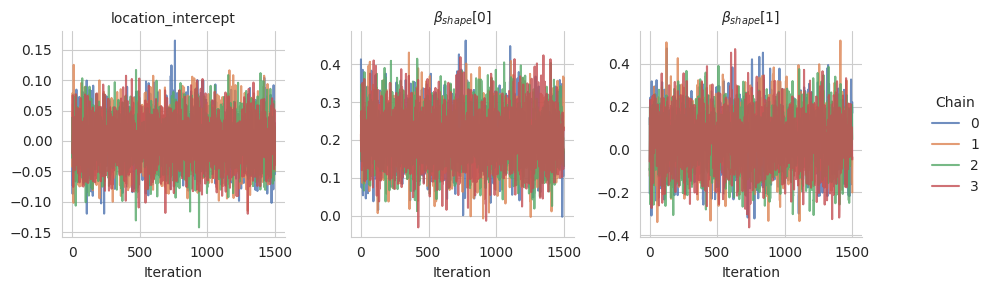

In [11]:
gs.plot_trace(results, [location_intercept.name, shape_linear.coef.name])

The retained draws have no divergences, a maximum R-hat of about 1.002,
and a minimum bulk ESS of about 1,609 across parameter blocks. The error table
also shows 151 divergences during warmup. Keep these adaptation errors in view
and recheck both phases when changing the data, starting values, or model,
especially because the GEV support depends on its parameters.

Distinguish warmup errors, when NUTS is adapting, from errors in retained
posterior draws. Check every parameter block, not just the displayed traces. In a
support-dependent model, divergences or persistent separation between chains
are reasons to investigate the model, starts, parameterization, and sampler
settings before using posterior summaries. A rejected proposal outside support
is not by itself evidence of an incorrect likelihood.

## Recover the curves

Each distribution parameter depends on a different covariate. The aligned rows
below vary all three covariates on the same grid; each predictor uses only its
own input. If predictors shared inputs or included interactions, specify which
other inputs are held fixed when displaying a slice.

Scale is predicted on its positive response-parameter scale within every draw.
The bands describe parameter uncertainty, not variation in future GEV responses.

In [12]:
grid = jnp.linspace(0.0, 1.0, 100)
predicted = model.predict(
    samples,
    predict=["loc", "scale", "concentration"],
    newdata=gs.Position({"x0": grid, "x1": grid, "x2": grid}),
)

truth = {
    "loc": np.sin(2.0 * np.pi * np.asarray(grid)),
    "scale": np.exp(-0.5 + 0.4 * np.asarray(grid)),
    "concentration": 0.15 + 0.1 * np.asarray(grid),
}
curve_summaries = []

for name, draws in predicted.items():
    curve = gs.SamplesSummary({name: draws}).to_dataframe().reset_index()
    curve["x"] = np.asarray(grid)
    curve["truth"] = truth[name]
    curve_summaries.append(curve)

curves = pd.concat(curve_summaries, ignore_index=True)
curves["parameter"] = curves["variable"].map(
    {"loc": "Location (x0)", "scale": "Scale (x1)", "concentration": "Shape (x2)"},
)

(spline)=

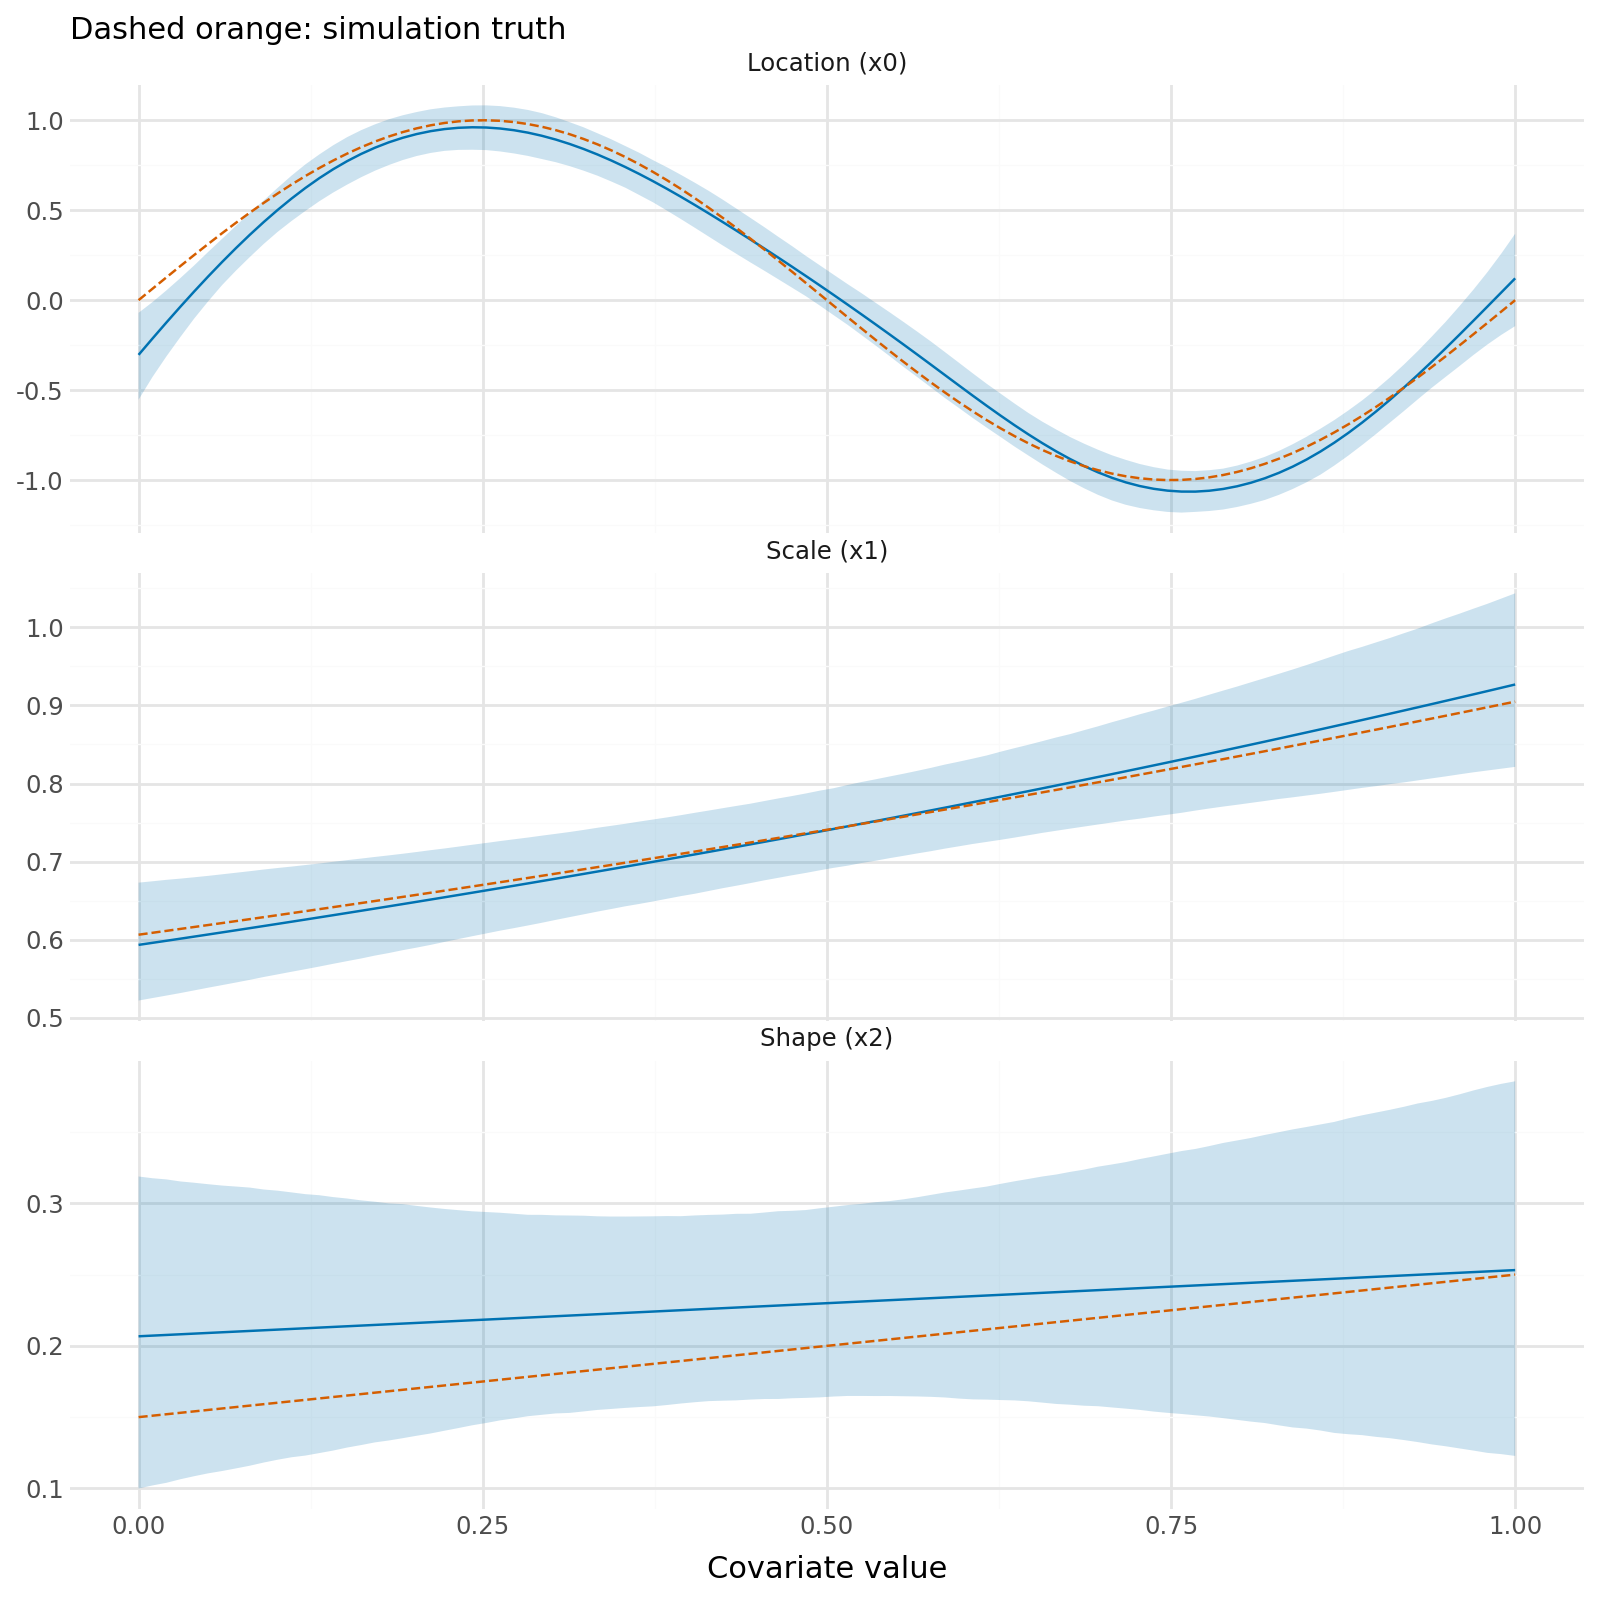

In [13]:
(
    p9.ggplot(curves, p9.aes("x", "mean"))
    + p9.geom_ribbon(p9.aes(ymin="q_0.05", ymax="q_0.95"), fill="#0072B2", alpha=0.2)
    + p9.geom_line(color="#0072B2")
    + p9.geom_line(p9.aes(y="truth"), color="#D55E00", linetype="dashed")
    + p9.facet_wrap("~parameter", scales="free_y", ncol=1)
    + p9.labs(x="Covariate value", y="", subtitle="Dashed orange: simulation truth")
    + p9.theme_minimal()
    + p9.theme(figure_size=(8, 8))
)

The location recovers the sinusoidal pattern and scale increases with its
covariate. Shape is less precisely estimated, and its generating curve lies
within a much wider band. A pointwise 90%
band need not contain the whole generating function. In an application without
known truth, investigate prior sensitivity, covariate effects on shape, and tail
behavior with {doc}`posterior predictive checks <../../model-simulation>`.